In [2]:
import os

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import matplotlib.pyplot as plt


# Load the saved features
df = pd.read_csv('data/mfcc_features.csv')
print(df.shape)
print(df.head())

(999, 14)
       mfcc_0     mfcc_1     mfcc_2     mfcc_3     mfcc_4     mfcc_5  \
0 -113.619385  121.55302 -19.151056  42.345768  -6.371168  18.613033   
1 -207.581510  123.99715   8.939115  35.870758   2.919970  21.518787   
2  -90.776344  140.44861 -29.100560  31.687340 -13.975973  25.741686   
3 -199.462000  150.09474   5.649167  26.870144   1.755440  14.236880   
4 -160.291850  126.19576 -35.602500  22.151167 -32.487640  10.862023   

      mfcc_6     mfcc_7     mfcc_8     mfcc_9    mfcc_10   mfcc_11   mfcc_12  \
0 -13.692060  15.339379 -12.283617  10.973775  -8.322410  8.806788 -3.665802   
1  -8.555368  23.355938 -10.101037  11.906445  -5.558123  5.375942 -2.237833   
2 -13.644712  11.623112 -11.775921   9.700466 -13.115349  5.785764 -8.899733   
3  -4.828873   9.297849  -0.753142   8.147393  -3.195236  6.085354 -2.476188   
4 -23.357162   0.500523 -11.804770   1.203878 -13.085074 -2.809849 -6.935621   

   genre  
0  blues  
1  blues  
2  blues  
3  blues  
4  blues  


In [4]:
print(df.isnull().sum())
print(df.dtypes)

mfcc_0     0
mfcc_1     0
mfcc_2     0
mfcc_3     0
mfcc_4     0
mfcc_5     0
mfcc_6     0
mfcc_7     0
mfcc_8     0
mfcc_9     0
mfcc_10    0
mfcc_11    0
mfcc_12    0
genre      0
dtype: int64
mfcc_0     float64
mfcc_1     float64
mfcc_2     float64
mfcc_3     float64
mfcc_4     float64
mfcc_5     float64
mfcc_6     float64
mfcc_7     float64
mfcc_8     float64
mfcc_9     float64
mfcc_10    float64
mfcc_11    float64
mfcc_12    float64
genre       object
dtype: object


In [5]:
# Separate features and labels
X = df.drop('genre', axis=1).values
y = df['genre'].values

# Encode genre labels to numbers
le = LabelEncoder()
y = le.fit_transform(y)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Classes: {le.classes_}")

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

X shape: (999, 13)
y shape: (999,)
Classes: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']

Train size: (799, 13)
Test size: (200, 13)


In [6]:
df.describe()

,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12
count,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000
mean,-144.529693,99.529891,-8.930675,36.307606,-1.154265,14.644125,-5.134419,10.128464,-7.002739,7.734505,-6.025621,4.476534,-4.799644
std,100.274375,31.334739,21.702666,16.668253,12.227953,11.844153,9.946546,10.467766,8.287131,7.941935,6.822006,6.719572,6.174329
min,-552.106300,-1.539154,-89.896150,-18.786009,-38.915707,-28.421492,-32.945824,-24.940002,-31.656443,-12.049384,-28.050291,-15.806172,-27.549044
25%,-200.849765,76.792130,-24.230801,24.135523,-9.993215,5.086104,-12.881134,1.608218,-13.268686,1.619162,-10.973778,-0.556677,-9.367917
50%,-120.324814,98.399030,-10.732934,36.979443,-0.045610,15.036698,-5.734196,9.662233,-7.582158,7.148099,-5.929299,3.899372,-4.222730
75%,-73.791945,119.732930,5.539077,48.259082,7.909429,23.859727,2.977368,18.728801,-0.379522,14.399079,-0.987131,9.710947,-0.156274
max,42.112865,193.094480,56.636234,80.692480,31.457941,45.167534,21.824984,49.023754,19.130112,27.228352,17.423235,23.026806,13.060921


In [7]:
# Fit ONLY on training data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)  # transform only, never fit

In [8]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
# Evaluate
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy*100:.2f}%")

Random Forest Accuracy: 56.00%


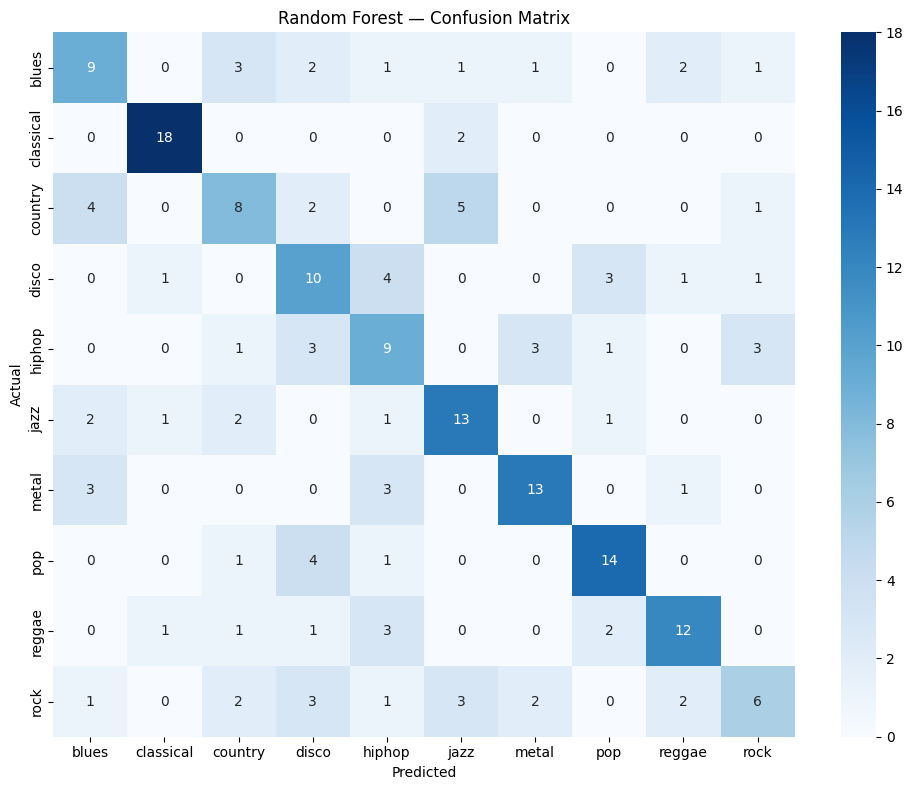

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Random Forest — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## "The model learned that classical music is highly distinct, while rock was hardest to classify due to its stylistic overlap with other genres — consistent with musicological literature."

 We only gave the model 13 numbers per song. That's a very compressed representation. What if we gave it more features?
Right now we only used MFCC means. But remember the MFCC matrix was shape (13, 1292) — we threw away all the time information by averaging. We could also extract:

MFCC standard deviation — how much do the coefficients vary over time?
Chroma features — pitch class information (which musical notes are present)
Spectral centroid — where is the "center of mass" of the spectrum (brightness of sound)
Spectral rolloff — at what frequency is 85% of energy contained
Zero crossing rate — how often does the signal cross zero (percussiveness)



In [11]:
def extract_features(file_path):
    y, sr = librosa.load(file_path, duration=30)
    
    # MFCCs — mean and std
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_mean = mfccs.mean(axis=1)
    mfcc_std = mfccs.std(axis=1)
    
    # Chroma — pitch class energy
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma_mean = chroma.mean(axis=1)
    
    # Spectral centroid — brightness
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    centroid_mean = centroid.mean()
    
    # Spectral rolloff
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    rolloff_mean = rolloff.mean()
    
    # Zero crossing rate — percussiveness
    zcr = librosa.feature.zero_crossing_rate(y)
    zcr_mean = zcr.mean()
    
    return [*mfcc_mean, *mfcc_std, *chroma_mean, 
            centroid_mean, rolloff_mean, zcr_mean]

In [12]:
features = []

genres = ['blues', 'classical', 'country', 'disco', 'hiphop', 
          'jazz', 'metal', 'pop', 'reggae', 'rock']

for genre in genres:
    genre_path = f'data/genres_original/{genre}'
    for filename in os.listdir(genre_path):
        if filename.endswith('.wav'):
            file_path = os.path.join(genre_path, filename)
            try:
                feat = extract_features(file_path)
                features.append([*feat, genre])
            except Exception as e:
                print(f"Error with {filename}: {e}")

# Build DataFrame
mfcc_cols = [f'mfcc_mean_{i}' for i in range(13)]
mfcc_std_cols = [f'mfcc_std_{i}' for i in range(13)]
chroma_cols = [f'chroma_{i}' for i in range(12)]
other_cols = ['centroid', 'rolloff', 'zcr']

columns = mfcc_cols + mfcc_std_cols + chroma_cols + other_cols + ['genre']
df_rich = pd.DataFrame(features, columns=columns)

df_rich.to_csv('data/rich_features.csv', index=False)
print(df_rich.shape)

C:\Users\Dell\AppData\Local\Temp\ipykernel_30084\2201460003.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, duration=30)
C:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error with jazz.00054.wav: 
(999, 42)


In [13]:
df_rich = pd.read_csv('data/rich_features.csv')

X = df_rich.drop('genre', axis=1).values
y = df_rich['genre'].values

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy*100:.2f}%")

Random Forest Accuracy: 66.00%


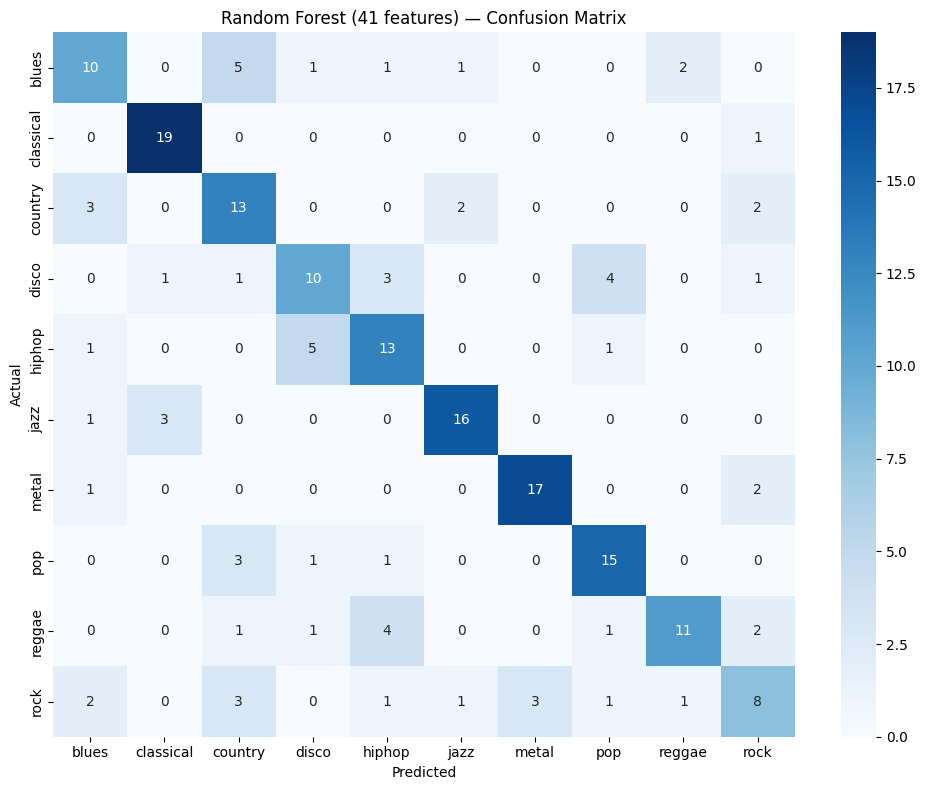

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Random Forest (41 features) — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Results

### Model Comparison
| Model | Features | Accuracy |
|-------|----------|----------|
| Random Forest | 13 (MFCC mean) | 56% |
| Random Forest | 41 (rich features) | 66% |

### Key Observations

**What the model learned well:**
- Classical music achieved highest accuracy (95%) — 
  distinct timbre separates it clearly from all other genres
- Metal improved significantly (85%) with richer features — 
  ZCR and spectral centroid capture its high-energy, 
  bright characteristic effectively

**Where the model struggles:**
- Rock was hardest to classify (40%) — stylistically 
  it borrows elements from metal, country, and jazz, 
  making its MFCC fingerprint inconsistent
- Reggae/hiphop confusion persists — both share similar 
  rhythmic patterns and bass-heavy spectral profiles
- Disco/pop overlap expected — similar production era 
  and instrumentation

**Signal processing insight:**
- Adding MFCC standard deviation captured temporal dynamics, 
  explaining the country improvement (quiet verses, 
  loud choruses create distinctive std patterns)
- Chroma features drove jazz improvement — jazz uses 
  complex harmonic progressions distinct from other genres
- Zero crossing rate successfully differentiates 
  percussive genres (metal, rock) from tonal ones 
  (classical, jazz)

In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_*100:.2f}%")

# Evaluate on test set
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 200}
Best CV score: 67.08%
Test accuracy: 64.00%


### Hyperparameter Tuning (GridSearchCV)

Best parameters found:
- `max_depth`: None (trees grow fully — data complexity requires depth)
- `max_features`: log2 (fewer features per split reduces tree correlation)
- `n_estimators`: 200
- `min_samples_split`: 5

**Key insight:** Tuned model (64%) performed slightly worse than 
untuned (66%) on test set — classic small dataset problem. 
With only ~100 samples per genre, CV scores don't always 
generalize perfectly. This suggests Random Forest with 
handcrafted features has hit its ceiling around 65-67%.

**This motivated moving to CNNs** — instead of manually 
engineering features, let the model learn directly from 
spectrograms treated as images.

In [16]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {svm_accuracy*100:.2f}%")

SVM Accuracy: 66.00%


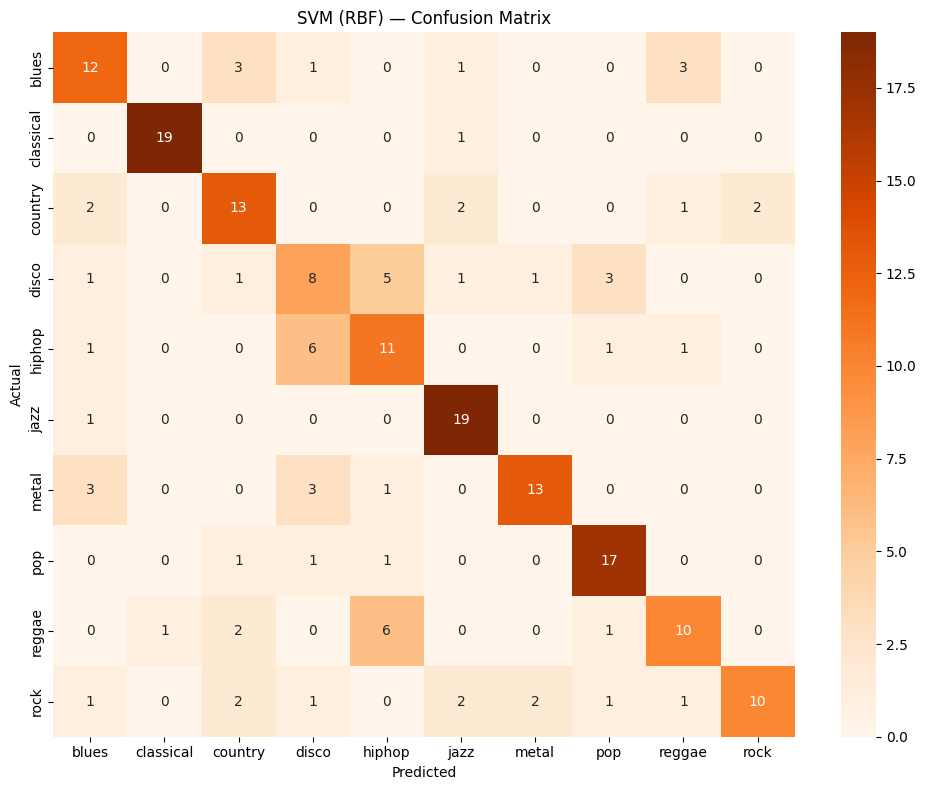

In [17]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('SVM (RBF) — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### SVM vs Random Forest Comparison

Both models plateau at ~66% — confirming the ceiling 
is feature quality, not model choice.

Notable difference:
- SVM excels at tight clusters (jazz 95%, pop 85%)
- Random Forest handles messy boundaries better (metal 85%)

**Conclusion:** Handcrafted features limit both models equally.
Moving to CNN on raw spectrograms to let the model learn 
its own features.

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01],
    'kernel': ['rbf']
}

grid_search_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_svm.fit(X_train, y_train)

print(f"Best params: {grid_search_svm.best_params_}")
print(f"Best CV score: {grid_search_svm.best_score_*100:.2f}%")

best_svm = grid_search_svm.best_estimator_
y_pred_svm_tuned = best_svm.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred_svm_tuned)*100:.2f}%")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV score: 72.96%
Test accuracy: 71.00%


In [19]:
param_grid_extended = {
    'C': [10, 50, 100, 200],
    'gamma': [0.001, 0.005, 0.01, 0.05],
    'kernel': ['rbf']
}

grid_search_svm2 = GridSearchCV(
    SVC(random_state=42),
    param_grid_extended,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_svm2.fit(X_train, y_train)

print(f"Best params: {grid_search_svm2.best_params_}")
print(f"Best CV score: {grid_search_svm2.best_score_*100:.2f}%")

best_svm2 = grid_search_svm2.best_estimator_
y_pred_svm2 = best_svm2.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred_svm2)*100:.2f}%")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV score: 72.96%
Test accuracy: 71.00%


### SVM GridSearch Results

Best params: C=10, gamma=0.01

Tuned SVM jumped to **71%** — breaking through the 66% 
ceiling that both untuned models hit.

SVM outperforms Random Forest on this dataset because:
- Small dataset (~100 samples per genre) favors max-margin classifiers
- High dimensional feature space (41D) suits SVM's kernel trick
- RBF kernel with low gamma creates smooth genre boundaries

**Final classical ML result: 71% accuracy**
Next step: CNN on spectrograms to push beyond this ceiling.